In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "Qwen/Qwen1.5-MoE-A2.7B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto"
)
model.eval()

/home/user2/miniforge3/envs/giangntt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 8/8 [00:05<00:00,  1.51it/s]


Qwen2MoeForCausalLM(
  (model): Qwen2MoeModel(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-23): 24 x Qwen2MoeDecoderLayer(
        (self_attn): Qwen2MoeSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): Qwen2MoeRotaryEmbedding()
        )
        (mlp): Qwen2MoeSparseMoeBlock(
          (gate): Linear(in_features=2048, out_features=60, bias=False)
          (experts): ModuleList(
            (0-59): 60 x Qwen2MoeMLP(
              (gate_proj): Linear(in_features=2048, out_features=1408, bias=False)
              (up_proj): Linear(in_features=2048, out_features=1408, bias=False)
              (down_proj): Linear(in_features=1408, out_features=2048, bias=False)
        

In [2]:
from utils.data_utils import create_packed_dataloader
loader = create_packed_dataloader(tokenizer, "brando/small-c4-dataset", split="train", sample_size=512, max_length=512)

In [3]:
# Collect router logits using utility function
from utils.router_utils import collect_router_logits_from_loader

result = collect_router_logits_from_loader(model, loader)
router_logits = result['router_logits']

To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you

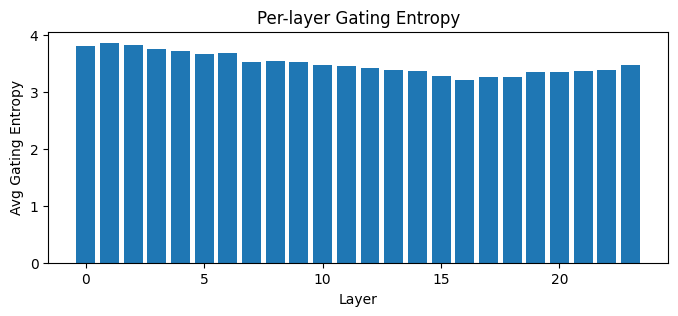

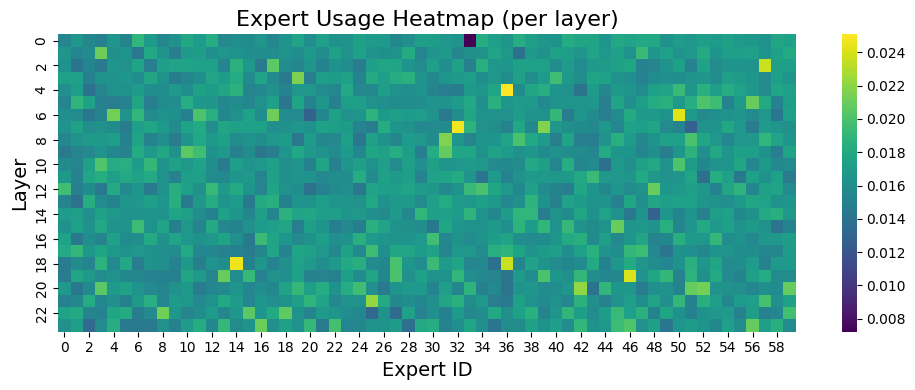

In [4]:
import torch
# Use utility function for expert usage and entropy analysis
from utils.analysis_utils import analyze_expert_usage_entropy
from utils.visualization_utils import plot_bar, plot_matrix, plot_histogram

layer_entropy, expert_usage = analyze_expert_usage_entropy(router_logits, top_k=4)

# ---- plot layer entropy ----
plot_bar(
    layer_entropy,
    xlabel="Layer",
    ylabel="Avg Gating Entropy",
    title="Per-layer Gating Entropy"
)

# ---- plot expert usage heatmap ----
usage_matrix = torch.stack(expert_usage).numpy()  # [num_layers, num_experts]
plot_matrix(
    usage_matrix,
    figsize=(10, 4),
    cmap="viridis",
    xlabel="Expert ID",
    ylabel="Layer",
    title="Expert Usage Heatmap (per layer)"
)

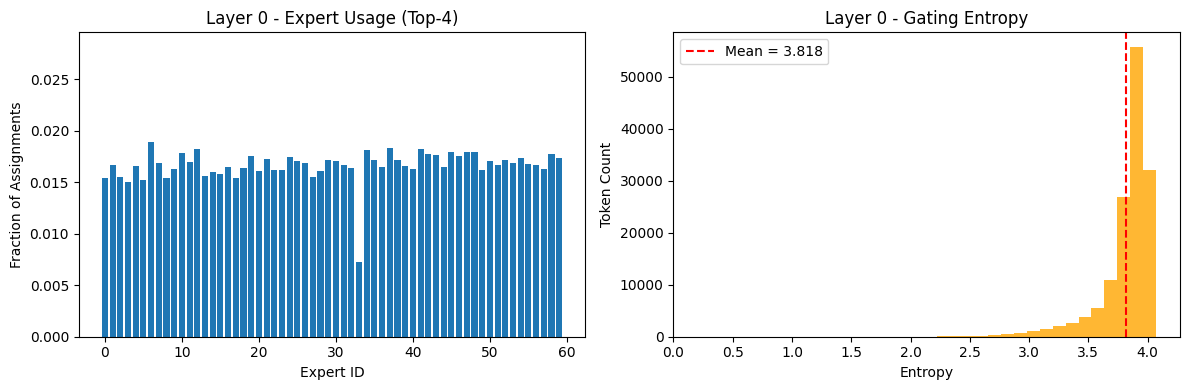

Layer 0: mean_entropy=3.818, std_entropy=0.235, num_tokens=144384


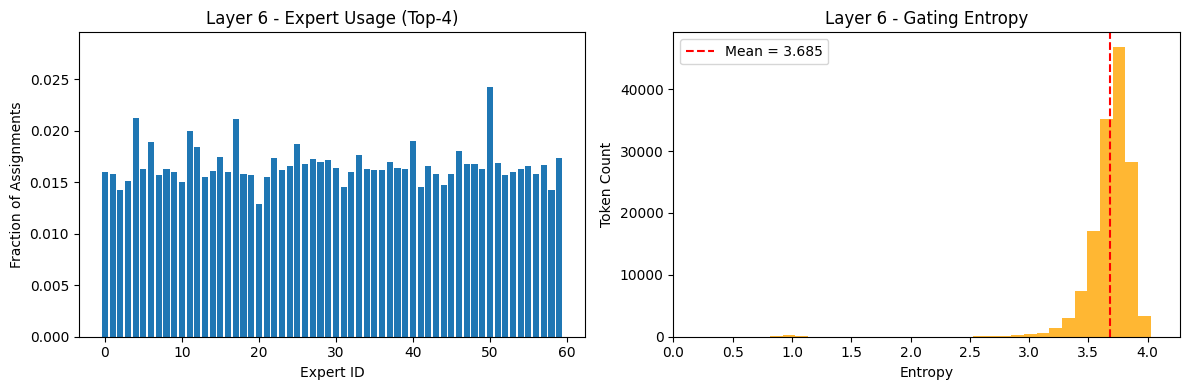

Layer 6: mean_entropy=3.685, std_entropy=0.228, num_tokens=144384


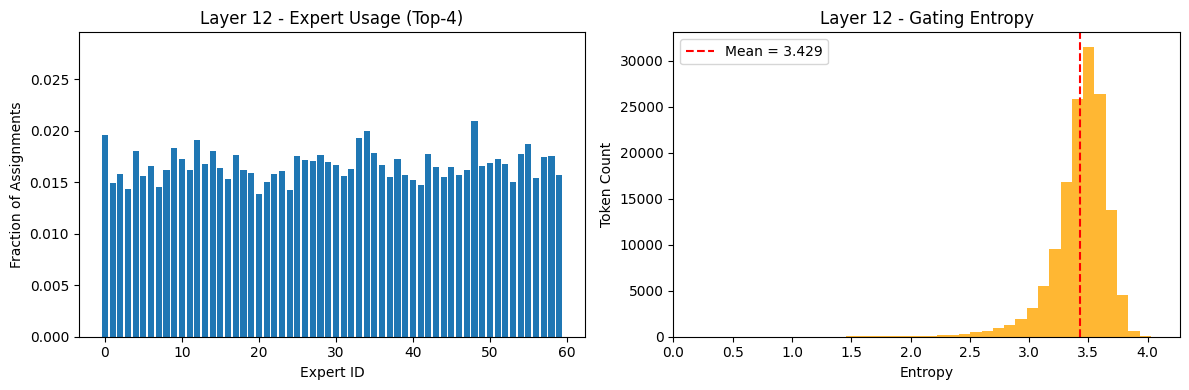

Layer 12: mean_entropy=3.429, std_entropy=0.245, num_tokens=144384


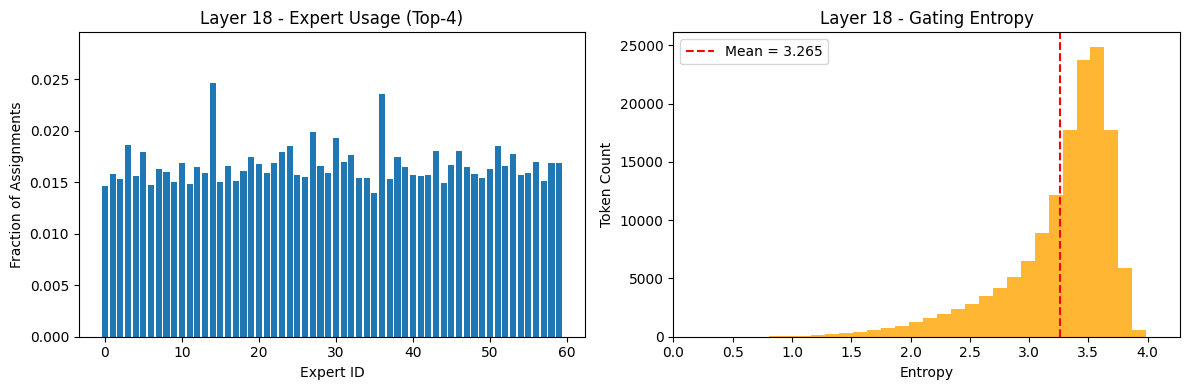

Layer 18: mean_entropy=3.265, std_entropy=0.462, num_tokens=144384


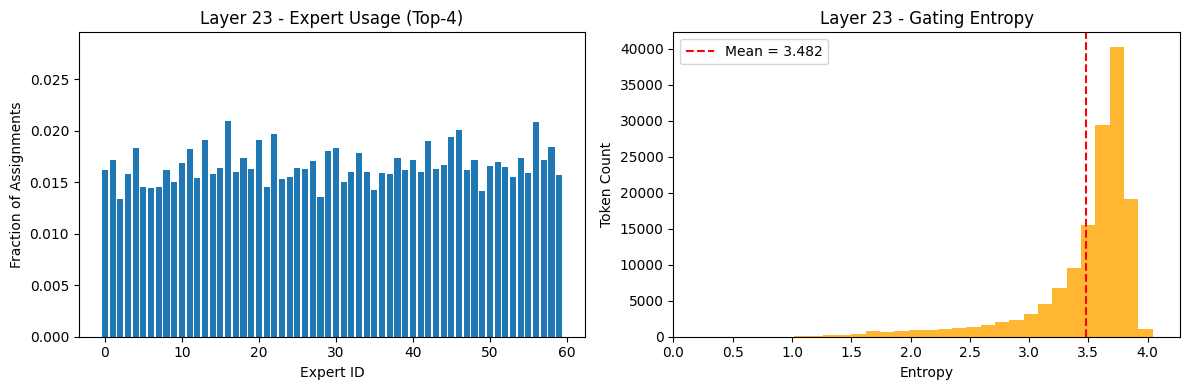

Layer 23: mean_entropy=3.482, std_entropy=0.456, num_tokens=144384


In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def analyze_and_plot_layers(router_logits, layers_to_plot=None, top_k=8):
    """
    Analyze MoE router logits per selected layers:
    - Expert usage (all tokens, top-k)
    - Token gating entropy distribution

    Args:
        router_logits: dict[layer_idx] = tensor [num_tokens, num_experts]
        layers_to_plot: list of layer indices to plot (e.g., [0, 5, 11, 23])
        top_k: number of experts per token to consider (top-k routing)
    """

    if layers_to_plot is None:
        layers_to_plot = sorted(router_logits.keys())

    global_usage_max = 0.0
    global_entropy_max = 0.0
    layer_stats = {}

    # -------- Pass 1: collect statistics --------
    for layer_id in layers_to_plot:
        if layer_id not in router_logits:
            print(f"Warning: layer {layer_id} not found, skipping.")
            continue

        logits = router_logits[layer_id]
        if logits.numel() == 0:
            print(f"Layer {layer_id} has empty tensor, skipping.")
            continue

        probs = F.softmax(logits, dim=-1)
        num_tokens, num_experts = probs.shape

        # Compute expert usage (top-k)
        topk_vals, topk_idx = torch.topk(probs, k=top_k, dim=-1)
        mask = torch.zeros_like(probs)
        mask.scatter_(1, topk_idx, 1.0)
        usage_counts = mask.sum(dim=0)
        usage_frac = usage_counts / usage_counts.sum()

        # Compute entropy
        token_entropies = -(probs * probs.clamp(min=1e-9).log()).sum(-1)
        mean_entropy = token_entropies.mean().item()
        std_entropy = token_entropies.std().item()

        global_usage_max = max(global_usage_max, usage_frac.max().item())
        global_entropy_max = max(global_entropy_max, token_entropies.max().item())

        layer_stats[layer_id] = {
            "usage_frac": usage_frac,
            "token_entropies": token_entropies,
            "mean_entropy": mean_entropy,
            "std_entropy": std_entropy,
            "num_tokens": num_tokens,
        }

    # -------- Pass 2: plotting --------
    for layer_id in layers_to_plot:
        if layer_id not in layer_stats:
            continue

        stats = layer_stats[layer_id]
        usage_frac = stats["usage_frac"]
        token_entropies = stats["token_entropies"]
        mean_entropy = stats["mean_entropy"]
        std_entropy = stats["std_entropy"]
        num_tokens = stats["num_tokens"]

        fig, axs = plt.subplots(1, 2, figsize=(12, 4))

        # 1️⃣ Expert usage
        plot_bar(usage_frac.cpu().numpy(), ax=axs[0], 
                 xlabel="Expert ID", ylabel="Fraction of Assignments", 
                 title=f"Layer {layer_id} - Expert Usage (Top-{top_k})",
                 ylim=(0, global_usage_max * 1.2))

        # 2️⃣ Entropy histogram
        plot_histogram(token_entropies.cpu().numpy(), ax=axs[1], bins=30, color="orange", alpha=0.8,
                      mean_line=mean_entropy, mean_label=f"Mean = {mean_entropy:.3f}",
                      title=f"Layer {layer_id} - Gating Entropy", xlabel="Entropy", ylabel="Token Count",
                      xlim=(0, global_entropy_max * 1.05))

        plt.tight_layout()
        plt.show()

        print(f"Layer {layer_id}: mean_entropy={mean_entropy:.3f}, std_entropy={std_entropy:.3f}, num_tokens={num_tokens}")

# Example usage:
analyze_and_plot_layers(router_logits, layers_to_plot=[0, 6, 12, 18, 23], top_k=4)


In [ ]:
# Use utility functions for expert sorting
import json
import os
from utils.analysis_utils import sort_experts_by_usage_or_prob

def save_sorted_experts(sorted_dict, output_path):
    """Save sorted expert indices per layer to JSON."""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "w") as f:
        json.dump(sorted_dict, f, indent=4)
    print(f"✅ Sorted experts saved to {output_path}")


def select_topk_experts(source, top_k=5, mode="most"):
    """
    Select top-k most or least used experts per layer from JSON or dict.

    Args:
        source: path to JSON file OR a dict[layer_id] = list of sorted experts
        top_k: number of experts to select
        mode: 'most' or 'least'

    Returns:
        selected_dict: dict[layer_id] = list of selected expert IDs
    """
    assert mode in ("most", "least"), "mode must be 'most' or 'least'"

    if isinstance(source, str):  # load from JSON
        with open(source, "r") as f:
            sorted_dict = json.load(f)
    else:
        sorted_dict = source

    selected_dict = {}
    for layer_id, experts in sorted_dict.items():
        layer_id = int(layer_id)
        if mode == "most":
            selected_dict[layer_id] = experts[:top_k]
        else:
            selected_dict[layer_id] = experts[-top_k:]

    return selected_dict


In [8]:
# Step 1 — sort experts by probability
sorted_experts = sort_experts_by_usage_or_prob(
    router_logits,
    top_k_routing=4,
    criterion="freq",
    descending=True
)

# Step 2 — save to JSON
output_dir = "prune_experts"
os.makedirs(output_dir, exist_ok=True)
save_sorted_experts(sorted_experts, f"{output_dir}/sorted_by_freq.json")

# Step 3 — select top-k experts (from file or dict)
most_used = select_topk_experts(f"{output_dir}/sorted_by_freq.json", top_k=10, mode="most")
least_used = select_topk_experts(sorted_experts, top_k=10, mode="least")


✅ Sorted experts saved to prune_experts/sorted_by_freq.json


In [6]:
# Use utility function for expert interactions
from utils.analysis_utils import analyze_expert_interactions

metrics = analyze_expert_interactions(router_logits, top_k_routing=4,
                                      metrics=("pattern_similarity", "conditional_probability", "jaccard_similarity"))

Analyzing expert overlap: 100%|██████████| 24/24 [00:00<00:00, 35.03it/s]


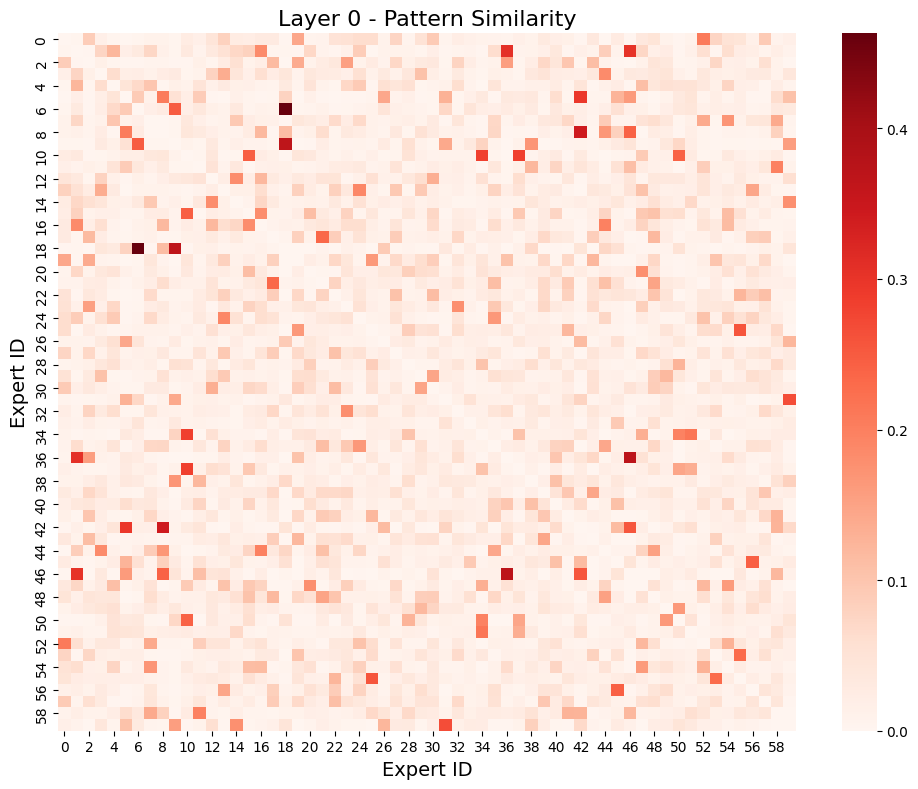

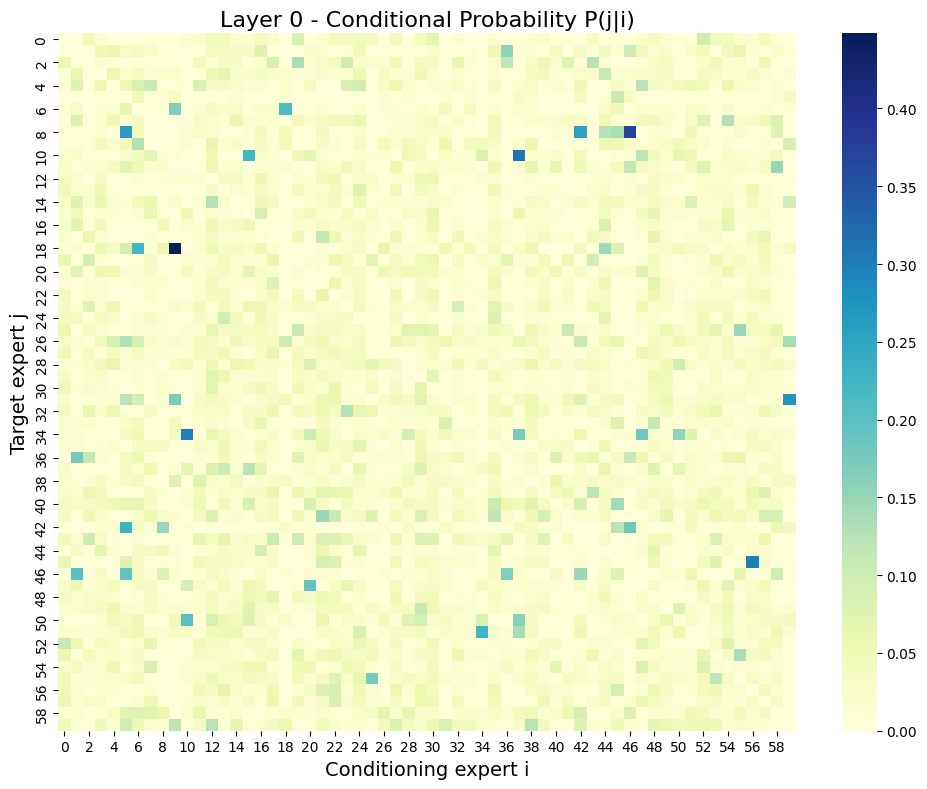

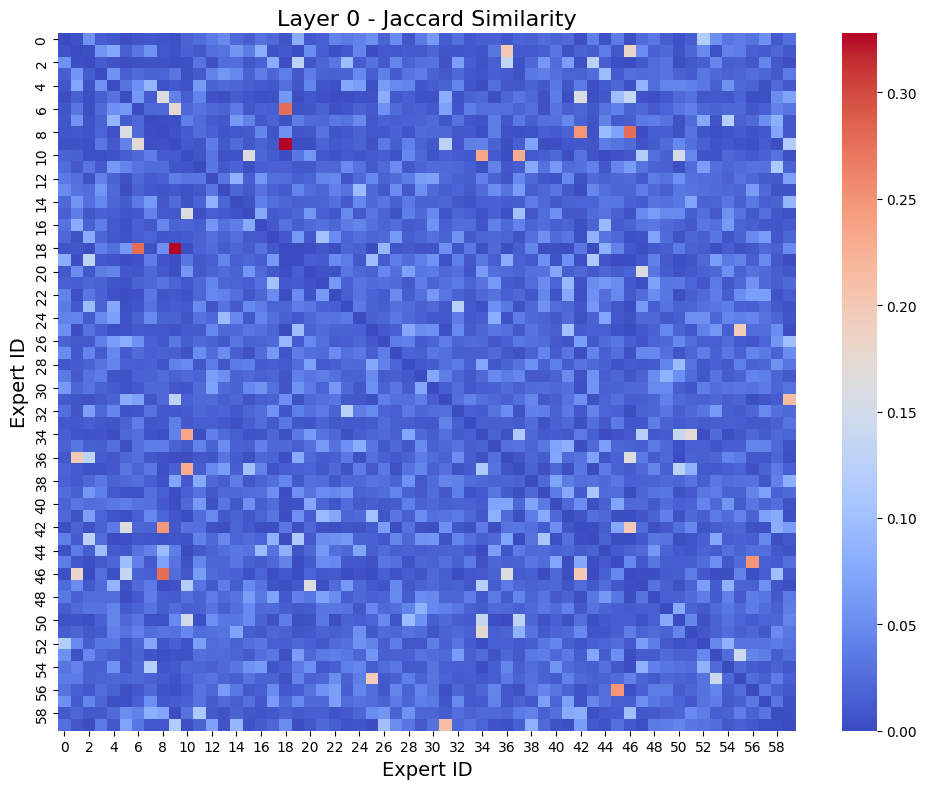

In [7]:
from utils.visualization_utils import plot_matrix

# 1. Plot pattern similarity matrix
plot_matrix(metrics[0]['pattern_similarity'], title="Layer 0 - Pattern Similarity", 
            xlabel="Expert ID", ylabel="Expert ID", cmap="Reds")

# 2. Plot conditional probability 
plot_matrix(metrics[0]['conditional_probability'], title="Layer 0 - Conditional Probability P(j|i)", 
            xlabel="Conditioning expert i", ylabel="Target expert j", cmap="YlGnBu", annot=False)

# 3. Plot jaccard similarity matrix
plot_matrix(metrics[0]['jaccard_similarity'], title="Layer 0 - Jaccard Similarity", 
            xlabel="Expert ID", ylabel="Expert ID", cmap="coolwarm")


In [8]:
# Use utility function for getting top pairs
from utils.analysis_utils import get_top_pairs

# Assume `metrics` is output from analyze_expert_interactions
top_pairs = get_top_pairs(metrics, top_k=5)

# Example: top 5 pattern similarity pairs in layer 0
print(top_pairs[0]["pattern_similarity"])
# Example: top 5 conditional probability pairs in layer 0
print(top_pairs[0]["conditional_probability"])
# Example: top 5 jaccard similarity pairs in layer 0
print(top_pairs[0]["jaccard_similarity"])

[(6, 18, 0.4630574584007263), (36, 46, 0.3703634440898895), (9, 18, 0.3657113313674927), (8, 42, 0.3427039384841919), (1, 36, 0.30623573064804077)]
[(18, 9, 0.4482722282409668), (8, 46, 0.37179630994796753), (10, 37, 0.3097268044948578), (34, 10, 0.29909566044807434), (45, 56, 0.2984728515148163)]
[(9, 18, 0.32779181003570557), (6, 18, 0.2774302661418915), (8, 46, 0.2772131562232971), (45, 56, 0.2486557513475418), (8, 42, 0.2475762963294983)]
